Creating Basic State Vectors

In [1]:
import numpy as np

# Define basis states
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])

print("|0⟩ =", ket_0)
print("|1⟩ =", ket_1)

|0⟩ = [1 0]
|1⟩ = [0 1]


Creating Superposition States

In [2]:
# Create superposition state |+⟩
alpha = 1/np.sqrt(2)  # Amplitude for |0⟩
beta = 1/np.sqrt(2)   # Amplitude for |1⟩

ket_plus = alpha * ket_0 + beta * ket_1

print("|+⟩ =", ket_plus)
print(f"\nProbability of |0⟩: {(np.abs(alpha)**2):.1f}")
print(f"Probability of |1⟩: {(np.abs(beta)**2):.1f}")

|+⟩ = [0.70710678 0.70710678]

Probability of |0⟩: 0.5
Probability of |1⟩: 0.5


Bloch Sphere Visualisation

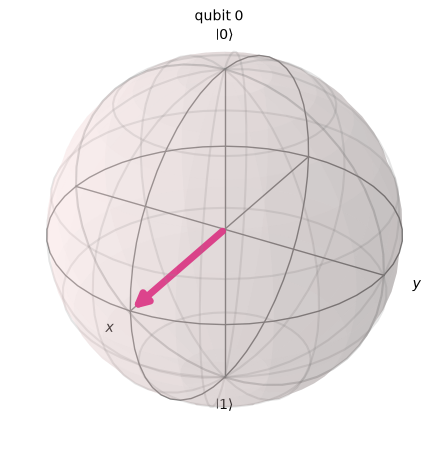

In [3]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Create the |+⟩ state
state = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])

# Plot on Bloch sphere
plot_bloch_multivector(state)

Creating Different Superposition States

In [4]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Define several states
states = {
    '|+⟩': [1/np.sqrt(2), 1/np.sqrt(2)],
    '|-⟩': [1/np.sqrt(2), -1/np.sqrt(2)],
    '|i⟩': [1/np.sqrt(2), 1j/np.sqrt(2)],
    '|-i⟩': [1/np.sqrt(2), -1j/np.sqrt(2)]
}

# Plot each state
for name, amps in states.items():
    state = Statevector(amps)
    formatted = [f"{a:.2f}" for a in amps]
    print(f"{name}: {formatted}")
    plot_bloch_multivector(state)


|+⟩: ['0.71', '0.71']
|-⟩: ['0.71', '-0.71']
|i⟩: ['0.71', '0.00+0.71j']
|-i⟩: ['0.71', '-0.00-0.71j']


Exploring Phase Effect

θ = 0.00: P(0) = 0.50, P(1) = 0.50
θ = 0.79: P(0) = 0.50, P(1) = 0.50
θ = 1.57: P(0) = 0.50, P(1) = 0.50
θ = 2.36: P(0) = 0.50, P(1) = 0.50
θ = 3.14: P(0) = 0.50, P(1) = 0.50


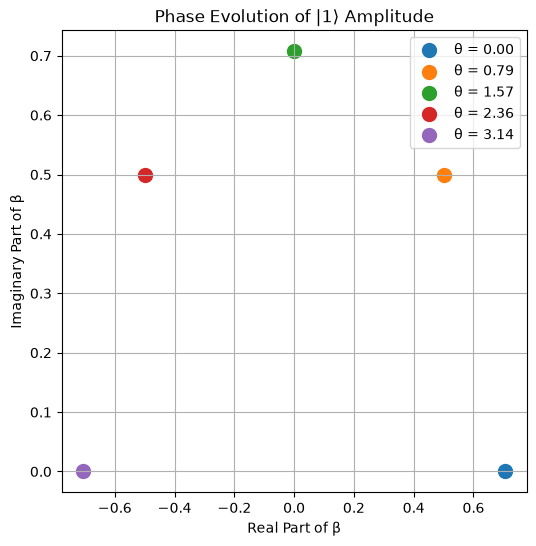

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Create states with different phases
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
phase_states = []

for theta in angles:
    # State: (|0⟩ + e^(iθ)|1⟩)/√2
    amp = [1/np.sqrt(2), np.exp(1j*theta)/np.sqrt(2)]
    phase_states.append(amp)
    
    # Calculate measurement probabilities
    prob_0 = np.abs(amp[0])**2
    prob_1 = np.abs(amp[1])**2
    print(f"θ = {theta:.2f}: P(0) = {prob_0:.2f}, P(1) = {prob_1:.2f}")

# Visualize phase evolution
fig, ax = plt.subplots(figsize=(6, 6))
for i, state in enumerate(phase_states):
    ax.scatter(np.real(state[1]), np.imag(state[1]),
               label=f'θ = {angles[i]:.2f}', s=100)
ax.set_xlabel('Real Part of β')
ax.set_ylabel('Imaginary Part of β')
ax.set_title('Phase Evolution of |1⟩ Amplitude')
ax.grid(True)
ax.legend()
plt.show()
